#Guilherme da Mata Garzon - 15456601
##Trabalho 2 - Simulação Numérica de Pêndulos

##1. Pêndulo Simples:

In [1]:
import numpy as np
import matplotlib as plot
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.special import ellipk, ellipj
q_0 = (np.pi)/4
p_0 = 0

In [2]:
def F(Y):
  return np.array([Y[1], -np.sin(Y[0])])

In [3]:
def sol_analitica(q_0,t):
    return 2 * (np.arcsin(np.sin(q_0/2) * ellipj(ellipk(np.sin(q_0/2)**2) - t, np.sin(q_0/2)**2)[0]))

###1.1.1 Método de Euler Explícito

In [4]:
def euler_explicito(q_0,p_0,t_final,t_inicial,h):
  N = int((t_final - t_inicial)/h)
  Y = np.zeros((N + 1, 2))
  tempos = np.zeros((N+1))
  Y[0] = [q_0, p_0]
  tempos[0] = t_inicial
  for i in range (N):
    y_atual = Y[i]
    Y[i+1] = y_atual + h*F(y_atual)
    tempos[i+1] = tempos[0] + (i+1)*h
  return Y,tempos

###1.1.2 Runge Kutta 4

In [5]:
def RK4(q_0,p_0,t_final,t_inicial,h):
  N = int((t_final - t_inicial)/h)
  Y = np.zeros((N + 1, 2), dtype=float)
  tempos = np.zeros((N+1))
  Y[0] = [q_0, p_0]
  tempos[0] = t_inicial
  for i in range(N):
    y_atual = Y[i]
    k_1 = F(y_atual)
    k_2 = F(y_atual + (h/2)*k_1)
    k_3 = F(y_atual + (h/2)*k_2)
    k_4 = F(y_atual + h*k_3)
    Y[i+1] = y_atual + (h/6)*(k_1 + 2*k_2 + 2*k_3 + k_4)
    tempos[i+1] = tempos[0] + (i+1)*h
  return Y, tempos

###1.1.3 Método Implícito

In [6]:
def J(Y,h):
  return np.array(([[1, -h],
                  [h*np.cos(Y[0]),1]]))
def G(U,Y,h):
  return U - Y -h*F(U)

def euler_implicito(q_0,p_0,t_final,t_inicial,h):
  N = int((t_final - t_inicial)/h)
  Y = np.zeros((N + 1, 2), dtype=float)
  tempos = np.zeros((N+1))
  tempos[0] = t_inicial
  Y[0] = [q_0, p_0]
  erro = 0.000000001
  for i in range (N):
    y_atual = Y[i]

    U = y_atual.copy()
    max_iter = 100
    delta = np.array([1.0, 1.0])
    for iteracao in range(max_iter):
      A = G(U,y_atual,h)
      B = J(U,h)
      delta = np.linalg.solve(B,-A)
      U = U + delta
      if np.linalg.norm(delta) <= erro:
        break
    Y[i+1] = U
    tempos[i+1] = tempos[0] + (i+1)*h

  return Y, tempos


###1.2 Resolução do Problema e Gráficos da Posição Angular

###1.2.1 Resolução do problema usando os 3 métodos

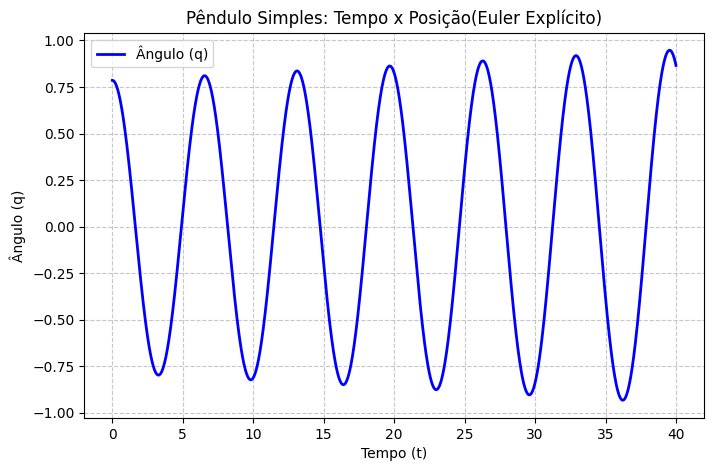

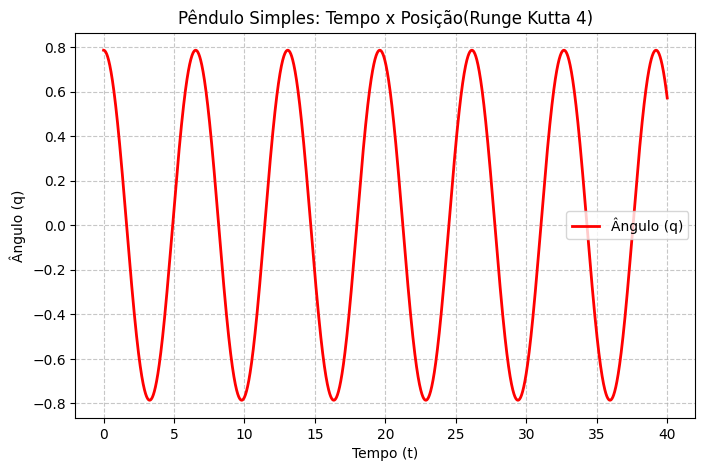

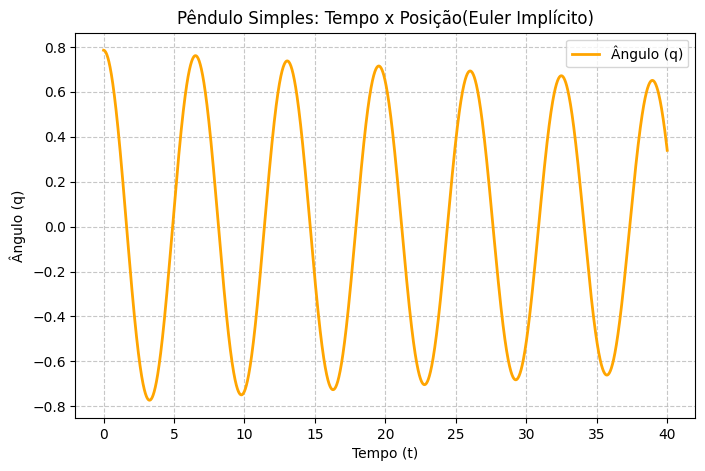

In [7]:
h = 0.01
t_inicial = 0
t_final = 40
Y, tempos_0 = euler_explicito(q_0,p_0,t_final,t_inicial,h)
X,tempos_1 = RK4(q_0,p_0,t_final,t_inicial,h)
Z,tempos_2 = euler_implicito(q_0,p_0,t_final,t_inicial,h)

#Euler Explicito
q_explicito = Y[:,0]
p_explicito = Y[:,1]
plt.figure(figsize=(8, 5))
plt.plot(tempos_0, q_explicito, label='Ângulo (q)', color='blue', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(Euler Explícito)')
plt.xlabel('Tempo (t)')
plt.ylabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#RK4
q_RK4 = X[:,0]
p_RK4 = X[:,1]
plt.figure(figsize=(8, 5))
plt.plot(tempos_0, q_RK4, label='Ângulo (q)', color='red', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(Runge Kutta 4)')
plt.xlabel('Tempo (t)')
plt.ylabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#Euler Implícito
q_implicito = Z[:,0]
p_implicito = Z[:,1]
plt.figure(figsize=(8, 5))
plt.plot(tempos_0, q_implicito, label='Ângulo (q)', color='orange', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(Euler Implícito)')
plt.xlabel('Tempo (t)')
plt.ylabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

###1.3 Gráficos de Convergência Temporal

Ordem de convergência calculada: p = 1.0079
Ordem de convergência calculada: p = 3.9883
Ordem de convergência calculada: p = 0.9913


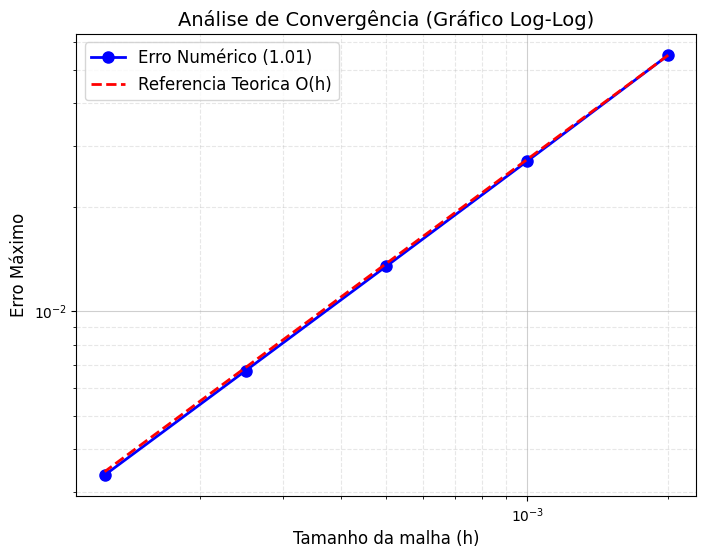

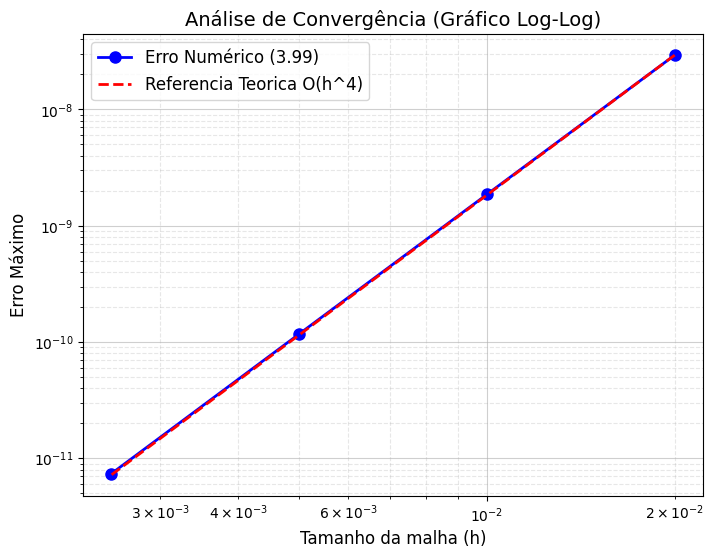

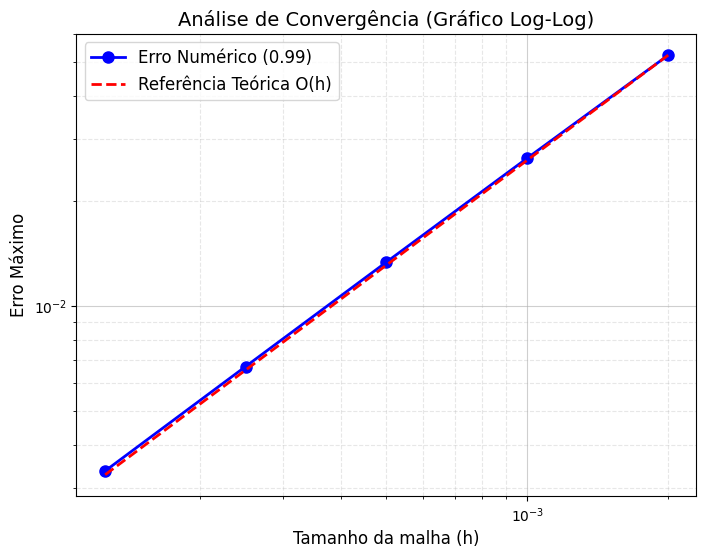

In [8]:
q_0 = (np.pi)/4
h = 0.002
h_RK4 = 0.04
h_valores = []
h_valores_RK4 = []
h_valores.append(h)
#Cria um vetor dos h's que serão usados
for t in range(4):
 h = h/2
 h_valores.append(h)

for t in range(4):
 h_RK4 = h_RK4/2
 h_valores_RK4.append(h_RK4)

erros_explicito = []
erros_RK4 = []
erros_implicito = []

#Faz a conta dos métodos de Euler
for h in h_valores:
  Y, _ = euler_explicito(q_0,p_0,t_final,t_inicial,h)
  Z, _ = euler_implicito(q_0,p_0,t_final,t_inicial,h)
  N = int((t_final - t_inicial) / h)
  tempos_perfeitos = np.linspace(t_inicial, t_final, N + 1)
  analitica = sol_analitica(q_0,tempos_perfeitos)
  erro_explicito = np.max(np.abs(Y[:,0] - analitica))
  erro_implicito = np.max(np.abs(Z[:,0] - analitica))
  erros_explicito.append(erro_explicito)
  erros_implicito.append(erro_implicito)


#Faz a conta do método RK4
for h_RK4 in h_valores_RK4:
  X, _ = RK4(q_0,p_0,t_final,t_inicial,h_RK4)
  N = int((t_final - t_inicial) / h_RK4)
  tempos_perfeitos_RK4 = np.linspace(t_inicial, t_final, N + 1)
  analitica_RK4 = sol_analitica(q_0,tempos_perfeitos_RK4)
  erro_RK4 = np.max(np.abs(X[:,0] - analitica_RK4))
  erros_RK4.append(erro_RK4)


#Erro do Euler Explícito
h_array = np.array(h_valores)
erros_array = np.array(erros_explicito)

#Calcula a ordem de convergência a partir do coeficiente angular
#da reta log log
p = np.polyfit(np.log(h_array), np.log(erros_array), 1)[0]
print(f"Ordem de convergência calculada: p = {p:.4f}")

#Cria a reta com o erro teórico O(h)
referencia_h2 = erros_array[0] * (h_array / h_array[0])

#Faz o plot dos gráficos
plt.figure(figsize=(8, 6))

#Plot dos erros numéricos (Azul pontilhada)
plt.loglog(h_array, erros_array, marker='o', linestyle='-', color='blue',
           linewidth=2, markersize=8, label=f'Erro Numérico ({p:.2f})')

#Plot da referência teórica (Vermelha tracejada)
plt.loglog(h_array, referencia_h2, linestyle='--', color='red',
           linewidth=2, label='Referencia Teorica O(h)')

#Formatação
plt.title('Análise de Convergência (Gráfico Log-Log)', fontsize=14)
plt.xlabel('Tamanho da malha (h)', fontsize=12)
plt.ylabel('Erro Máximo', fontsize=12)

#Grid logarítmico para facilitar a leitura
plt.grid(True, which="major", linestyle='-', alpha=0.6)
plt.grid(True, which="minor", linestyle='--', alpha=0.3)

plt.legend(fontsize=12)






#Erro do RK4
h_array = np.array(h_valores_RK4)
erros_array = np.array(erros_RK4)

#Calcula a ordem de convergência a partir do coeficiente angular
#da reta log log
p = np.polyfit(np.log(h_array), np.log(erros_array), 1)[0]
print(f"Ordem de convergência calculada: p = {p:.4f}")

#Cria a reta com o erro teórico O(h^4)
referencia_h2 = erros_array[0] * (h_array / h_array[0])**4

#Faz o plot dos gráficos
plt.figure(figsize=(8, 6))

#Plot dos erros numéricos (Azul pontilhada)
plt.loglog(h_array, erros_array, marker='o', linestyle='-', color='blue',
           linewidth=2, markersize=8, label=f'Erro Numérico ({p:.2f})')

#Plot da referência teórica (vermelha tracejada)
plt.loglog(h_array, referencia_h2, linestyle='--', color='red',
           linewidth=2, label='Referencia Teorica O(h^4)')

#Formatação
plt.title('Análise de Convergência (Gráfico Log-Log)', fontsize=14)
plt.xlabel('Tamanho da malha (h)', fontsize=12)
plt.ylabel('Erro Máximo', fontsize=12)

#Grid logarítmico para facilitar a leitura
plt.grid(True, which="major", linestyle='-', alpha=0.6)
plt.grid(True, which="minor", linestyle='--', alpha=0.3)

plt.legend(fontsize=12)







#Erro do Euler Implícito
h_array = np.array(h_valores)
erros_array = np.array(erros_implicito)

#Calcula a ordem de convergência a partir do coeficiente angular
#da reta log log
p = np.polyfit(np.log(h_array), np.log(erros_array), 1)[0]
print(f"Ordem de convergência calculada: p = {p:.4f}")

#Cria a reta com o erro teórico O(h)
referencia_h2 = erros_array[0] * (h_array / h_array[0])

#Faz o plot dos gráficos
plt.figure(figsize=(8, 6))

#Plot dos erros numéricos (Azul pontilhada)
plt.loglog(h_array, erros_array, marker='o', linestyle='-', color='blue',
           linewidth=2, markersize=8, label=f'Erro Numérico ({p:.2f})')

#Plot da referência teórica (vermelha tracejada)
plt.loglog(h_array, referencia_h2, linestyle='--', color='red',
           linewidth=2, label='Referência Teórica O(h)')

#Formatação
plt.title('Análise de Convergência (Gráfico Log-Log)', fontsize=14)
plt.xlabel('Tamanho da malha (h)', fontsize=12)
plt.ylabel('Erro Máximo', fontsize=12)

#Grid logarítmico para facilitar a leitura
plt.grid(True, which="major", linestyle='-', alpha=0.6)
plt.grid(True, which="minor", linestyle='--', alpha=0.3)

plt.legend(fontsize=12)




###1.4 Retratos de Fase

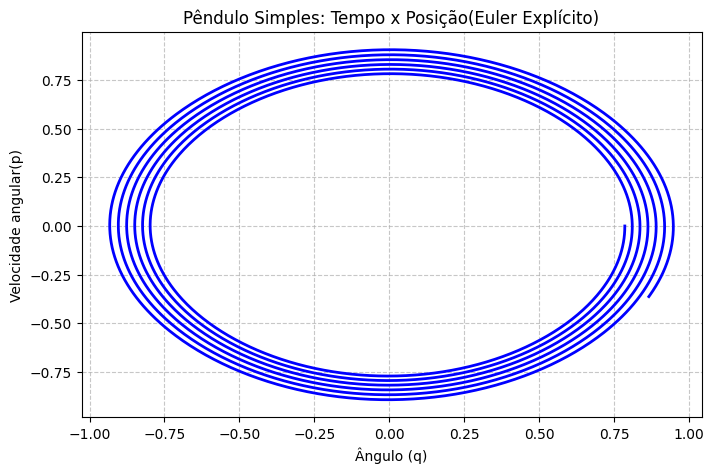

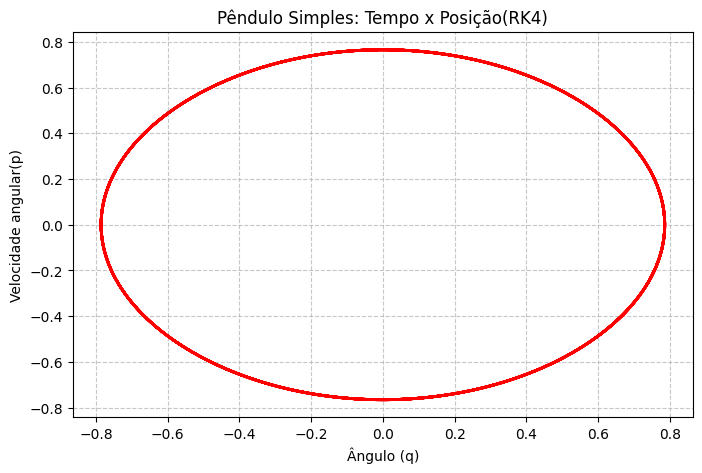

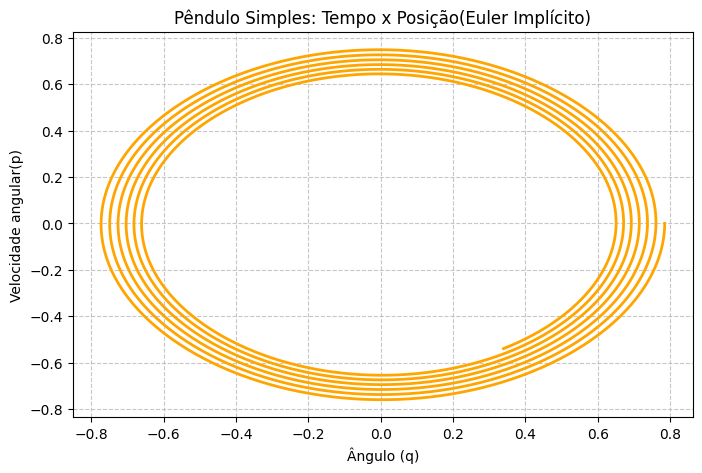

In [9]:
#Retrato de Fase Euler Explícito
plt.figure(figsize=(8, 5))
plt.plot(q_explicito, p_explicito, label='Ângulo (q)', color='blue', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(Euler Explícito)')
plt.ylabel('Velocidade angular(p)')
plt.xlabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)

#Retrato de Fase RK4
plt.figure(figsize=(8, 5))
plt.plot(q_RK4, p_RK4, label='Ângulo (q)', color='red', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(RK4)')
plt.ylabel('Velocidade angular(p)')
plt.xlabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)

#Retrato de Fase Euler Implícito
plt.figure(figsize=(8, 5))
plt.plot(q_implicito, p_implicito, label='Ângulo (q)', color='orange', linewidth=2)
plt.title('Pêndulo Simples: Tempo x Posição(Euler Implícito)')
plt.ylabel('Velocidade angular(p)')
plt.xlabel('Ângulo (q)')
plt.grid(True, linestyle='--', alpha=0.7)

##2. Pêndulo Duplo:

Antes de começar, escrevemos as funções e expressões auxiliares

In [10]:
def A_1(q1, q2, p1, p2):
    numerador = p1 * p2 * np.sin(q1 - q2)
    denominador = 1 + (np.sin(q1 - q2))**2
    return numerador / denominador

def A_2(q1, q2, p1, p2):
    numerador = (p1**2 + 2*(p2**2) - 2*p1*p2*np.cos(q1 - q2)) * np.sin(q1 - q2) * np.cos(q1 - q2)
    denominador = (1 + (np.sin(q1 - q2))**2)**2
    return numerador / denominador

def f_1(q1, q2, p1, p2):
    return (p1 - p2*np.cos(q1 - q2)) / (2 - (np.cos(q1 - q2))**2)

def f_2(q1, q2, p1, p2):
    return (2*p2 - p1*np.cos(q1 - q2)) / (2 - (np.cos(q1 - q2))**2)

def f_3(q1, q2, p1, p2):
    return -A_1(q1,q2,p1,p2) + A_2(q1,q2,p1,p2) - 2*np.sin(q1)

def f_4(q1, q2, p1, p2):
    return A_1(q1,q2,p1,p2) - A_2(q1,q2,p1,p2) - np.sin(q2)

def F_2(Y):
    return np.array([f_1(Y[0], Y[1], Y[2], Y[3]),
                     f_2(Y[0], Y[1], Y[2], Y[3]),
                     f_3(Y[0], Y[1], Y[2], Y[3]),
                     f_4(Y[0], Y[1], Y[2], Y[3])])

Escrevemos o RK4 para o pêndulo duplo

In [11]:
def RK4_2(q_1,q_2,p_1,p_2,t_final,t_inicial,h):
  N = int((t_final - t_inicial)/h)
  Y = np.zeros((N + 1, 4), dtype=float)
  tempos = np.zeros((N+1))
  Y[0] = [q_1, q_2,p_1,p_2]
  tempos[0] = t_inicial
  for i in range(N):
    y_atual = Y[i]
    k_1 = F_2(y_atual)
    k_2 = F_2(y_atual + (h/2)*k_1)
    k_3 = F_2(y_atual + (h/2)*k_2)
    k_4 = F_2(y_atual + h*k_3)
    Y[i+1] = y_atual + (h/6)*(k_1 + 2*k_2 + 2*k_3 + k_4)
    tempos[i+1] = tempos[0] + (i+1)*h
  return Y, tempos

###Primeira plotagem do pêndulo duplo

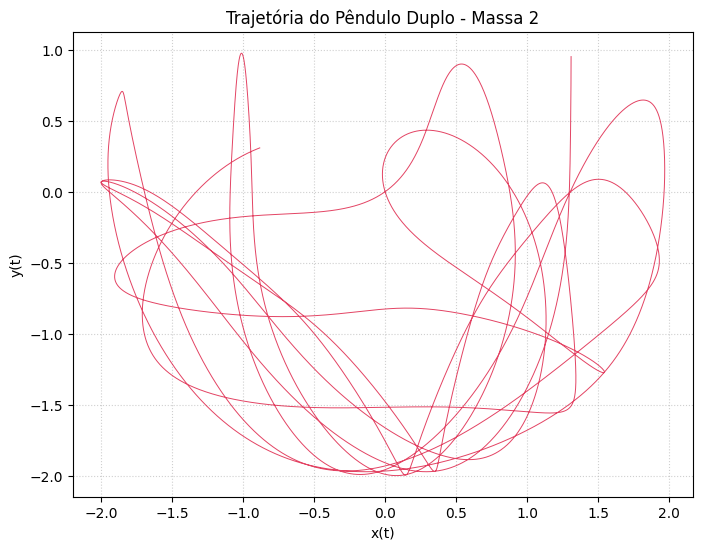

In [12]:
#Define as condições iniciais
h = 0.001
t_inicial = 0
t_final = 50
q_1 = np.pi/2
q_2 = 0.9*np.pi
p_1 = 0
p_2 = 0

#Resolve o RK4, guarda os valores e os tempos
X,tempos = RK4_2(q_1,q_2,p_1,p_2,t_final,t_inicial,h)


q1_RK4 = X[:,0]
q2_RK4 = X[:,1]
p1_RK4 = X[:,2]
p2_RK4 = X[:,3]

#Parâmetros Físicos(Comprimentos)
L1 = 1.0
L2 = 1.0

#Conversão para Coordenada Cartesianas
x1 = L1 * np.sin(q1_RK4)
y1 = -L1 * np.cos(q1_RK4)

x2 = x1 + L2 * np.sin(q2_RK4)
y2 = y1 - L2 * np.cos(q2_RK4)

#Cria a figura
fig, ax = plt.subplots(figsize=(8, 8))

#Plota traço do pêndulo debaixo
ax.plot(x2, y2, '-', color='crimson', lw=0.7, alpha=0.8)

#Configurações visuais do gráfico
ax.set_title("Trajetória do Pêndulo Duplo - Massa 2")
ax.set_xlabel("x(t)")
ax.set_ylabel("y(t)")

ax.set_aspect('equal')

ax.grid(True, linestyle=':', alpha=0.6)

# Mostra o gráfico final
plt.show()

###Experimento 1: Ângulos pequenos
Nesse experimento, vamos observar o que acontece em pêndulos que começam em ângulos pequenos

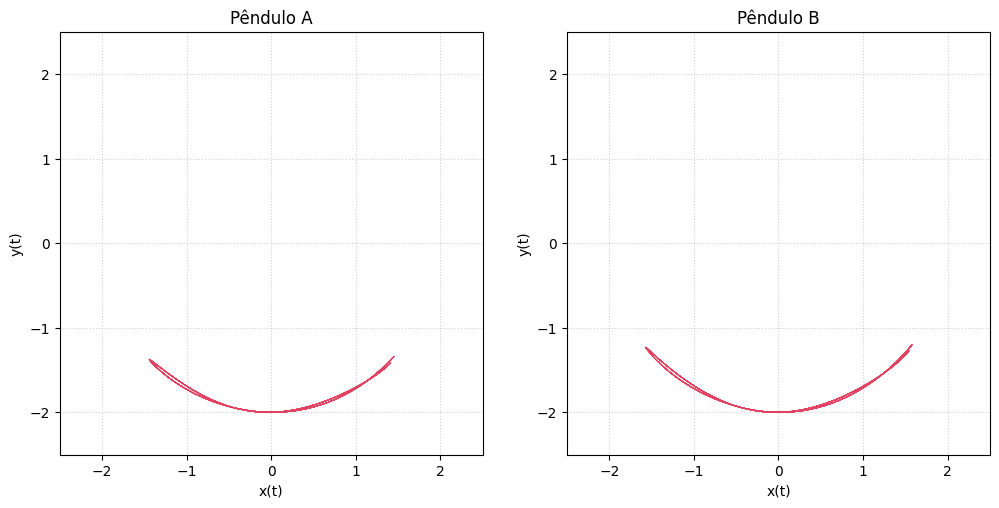

In [13]:
#Define as condições iniciais com ângulos pequenos
h = 0.05
t_inicial = 0
t_final = 50
q_1 = np.pi/4
q_2 = np.pi/4
p_1 = 0
p_2 = 0
q_12 = np.pi/4 + 0.1
q_22 = np.pi/4 + 0.1
p_12 = 0
p_22 = 0

#Resolve o RK4, guarda os valores e os tempos
X,tempos = RK4_2(q_1,q_2,p_1,p_2,t_final,t_inicial,h)
Y, tempos = RK4_2(q_12,q_22,p_12,p_22,t_final,t_inicial,h)

#Armazena os valores obtidos
#Pêndulo A
q1_RK4 = X[:,0]
q2_RK4 = X[:,1]
p1_RK4 = X[:,2]
p2_RK4 = X[:,3]

#Pêndulo B
q12_RK4 = Y[:,0]
q22_RK4 = Y[:,1]
p12_RK4 = Y[:,2]
p22_RK4 = Y[:,3]

#Parâmetros físicos(Comprimentos)
L1 = 1
L2 = 1

# Conversão para coordenadas cartesianas
#Primeiro Pêndulo
x1_A = L1 * np.sin(q1_RK4)
y1_A = -L1 * np.cos(q1_RK4)
x1_B = L1 * np.sin(q12_RK4)
y1_B = -L1 * np.cos(q12_RK4)

#Segundo Pêndulo
x2_A = x1_A + L2 * np.sin(q2_RK4)
y2_A = y1_A - L2 * np.cos(q2_RK4)
x2_B = x1_B + L2 * np.sin(q22_RK4)
y2_B = y1_B - L2 * np.cos(q22_RK4)

#Configuração da figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

limite = L1 + L2 + 0.5

#Configurações dos gráficos
for ax in (ax1, ax2):
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.set_aspect('equal')
    ax.grid(True)

ax1.set_title("Pêndulo A")
ax2.set_title("Pêndulo B")

ax1.plot(x2_A, y2_A, '-', color='crimson', lw=0.7, alpha=0.8)

ax1.set_xlabel("x(t)")
ax1.set_ylabel("y(t)")

ax2.plot(x2_B, y2_B, '-', color='crimson', lw=0.7, alpha=0.8)

ax2.set_xlabel("x(t)")
ax2.set_ylabel("y(t)")

ax1.set_aspect('equal')

ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_aspect('equal')

ax2.grid(True, linestyle=':', alpha=0.6)

# Mostra o gráfico final
plt.show()


###Experimento 2: Comportamento caótico
Para o segundo experimento, observamos como a trajetória é alterada ao variarmos muito pouco a posição inicial(variação de 0.01)

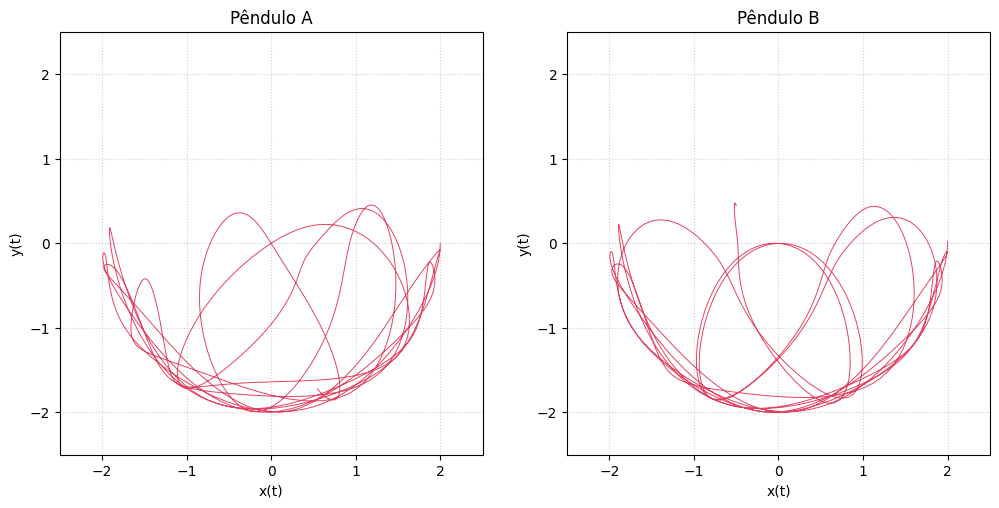

In [14]:
#Define as condições iniciais com ângulos fora da zona de equilíbrio
h = 0.05
t_inicial = 0
t_final = 50
q_1 = np.pi/2
q_2 = np.pi/2
p_1 = 0
p_2 = 0
q_12 = np.pi/2 + 0.01
q_22 = np.pi/2 + 0.01
p_12 = 0
p_22 = 0

#Resolve o RK4, guarda os valores e os tempos
X,tempos = RK4_2(q_1,q_2,p_1,p_2,t_final,t_inicial,h)
Y, tempos = RK4_2(q_12,q_22,p_12,p_22,t_final,t_inicial,h)

#Armazena os valores obtidos
#Pêndulo A
q1_RK4 = X[:,0]
q2_RK4 = X[:,1]
p1_RK4 = X[:,2]
p2_RK4 = X[:,3]

#Pêndulo B
q12_RK4 = Y[:,0]
q22_RK4 = Y[:,1]
p12_RK4 = Y[:,2]
p22_RK4 = Y[:,3]

#Parâmetros físicos(Comprimentos)
L1 = 1
L2 = 1

# Conversão para coordenadas cartesianas
#Primeiro Pêndulo
x1_A = L1 * np.sin(q1_RK4)
y1_A = -L1 * np.cos(q1_RK4)
x1_B = L1 * np.sin(q12_RK4)
y1_B = -L1 * np.cos(q12_RK4)

#Segundo Pêndulo
x2_A = x1_A + L2 * np.sin(q2_RK4)
y2_A = y1_A - L2 * np.cos(q2_RK4)
x2_B = x1_B + L2 * np.sin(q22_RK4)
y2_B = y1_B - L2 * np.cos(q22_RK4)

#Configuração da figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

limite = L1 + L2 + 0.5

#Configurações dos gráficos
for ax in (ax1, ax2):
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.set_aspect('equal')
    ax.grid(True)

ax1.set_title("Pêndulo A")
ax2.set_title("Pêndulo B")

ax1.plot(x2_A, y2_A, '-', color='crimson', lw=0.7, alpha=0.8)

ax1.set_xlabel("x(t)")
ax1.set_ylabel("y(t)")

ax2.plot(x2_B, y2_B, '-', color='crimson', lw=0.7, alpha=0.8)

ax2.set_xlabel("x(t)")
ax2.set_ylabel("y(t)")

ax1.set_aspect('equal')

ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_aspect('equal')

ax2.grid(True, linestyle=':', alpha=0.6)

# Mostra o gráfico final
plt.show()
